# KRX 지수 구성종목 파악

KRX 전체 **163개 지수** 목록을 조회하고, 각 지수에 포함된 종목을 확인합니다.

> **참고**: 2026년 2월부터 KRX가 로그인 없이는 API 조회를 막아 `fdr.SnapDataReader('KRX/INDEX/STOCK/...')` 가 대부분 실패합니다.  
> FinanceDataReader 팀이 GitHub 캐시를 제공하는 지수만 현재 조회 가능합니다.

In [92]:
import os
import sys
from pathlib import Path

# Flask 앱 서비스 모듈 사용 (동일 로직을 노트북에서도 실행)
sys.path.insert(0, str((Path('.') / '..' / 'flask').resolve()))

# 섹터 지수(1005~1027) 조회를 위해 KRX 로그인 설정 (선택)
# 1) https://data.krx.co.kr 회원가입 (네이버/카카오 간편가입 가능, 무료)
# 2) 아래 환경 변수 설정 또는 .env 파일 사용
# os.environ['KRX_ID'] = 'your_id'
# os.environ['KRX_PW'] = 'your_password'

from app.services.index_constituents import (
    get_krx_index_list,
    get_sector_indices,
    get_index_coverage,
    get_index_constituents,
    build_stock_index_map,
    krx_login_configured,
)

print('KRX 로그인 설정:', krx_login_configured())

In [93]:
# 1) 전체 지수 목록 (163개)
index_list = get_krx_index_list()
print(f'총 {len(index_list)}개 지수')
index_list.head(10)

총 163개 지수


,Code,Name,Market
0,1001,코스피,KOSPI
1,1002,코스피 대형주,KOSPI
2,1003,코스피 중형주,KOSPI
3,1004,코스피 소형주,KOSPI
4,1005,음식료·담배,KOSPI
5,1006,섬유·의류,KOSPI
6,1007,종이·목재,KOSPI
7,1008,화학,KOSPI
8,1009,제약,KOSPI
9,1010,비금속,KOSPI


In [94]:
# 2) 구성종목 데이터 조회 가능 여부
coverage = get_index_coverage()
print(f"조회 가능: {coverage['cached_indices']} / {coverage['total_indices']}")
coverage['cached_only']

조회 가능: 1 / 163


[{'code': '1001', 'name': '코스피', 'market': 'KOSPI', 'cached': True}]

In [98]:
# 3) 코스피(1001) 구성종목
kospi = get_index_constituents('1001')
print(f"{kospi['name']}: {kospi['count']}종목 (기준일 {kospi['as_of']})")

import pandas as pd
df = pd.DataFrame(kospi['constituents'])

코스피: 832종목 (기준일 2026-06-16)


In [101]:
df

,Code,Name,Close,Rate,Marcap
0,005930,삼성전자,343000,1.78,2005273562544000
1,000660,SK하이닉스,2382000,4.11,1697657033430000
2,402340,SK스퀘어,1501000,6.23,198069537386000
3,009150,삼성전기,2048000,2.45,152972689408000
4,005380,현대차,640000,-1.08,131044970240000
...,...,...,...,...,...
827,462520,조선내화,14870,0.20,176286348160
828,465770,STX그린로지스,2665,-2.20,19110800280
829,475560,더본코리아,16120,-0.68,239026876400
830,480370,씨케이솔루션,1704,-0.23,55348319232


In [ ]:
import pandas as pd

# 5) 섹터 지수 목록 + 구성종목 (로그인 필요)
sectors = get_sector_indices()
print(f'KOSPI 섹터 지수 {len(sectors)}개')
sectors

# 예: 전기전자(1013) 구성종목 — KRX_ID/KRX_PW 설정 후 실행
result = get_index_constituents('1013')
print(f"{result['name']}: {result['count']}종목 (source={result['source']})")
if result['available']:
    pd.DataFrame(result['constituents']).head(10)
else:
    print('조회 실패:', result['error'])

In [96]:
# 4) 종목 → 포함 지수 역매핑 (캐시된 지수 기준)
stock_map = build_stock_index_map()  # 현재는 1001(코스피)만
print(f"역매핑 종목 수: {stock_map['stock_count']}")

# 특정 종목이 어떤 지수에 포함되는지
stock_map['stock_map'].get('005930')

역매핑 종목 수: 832


{'symbol': '005930',
 'name': '삼성전자',
 'indices': [{'code': '1001', 'name': '코스피', 'market': 'KOSPI'}]}

In [97]:
import FinanceDataReader as fdr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib



In [ ]:
# 금, 암호화폐, 원/달러 환율 데이터 수집

# 금 시세(2003~현재)
gold = fdr.DataReader('GOLD')
gold.columns = ['gold_' + i for i in gold.columns]

# 암호화폐(비트코인/2014~현재)
btc = fdr.DataReader('BTC/USD')
btc.columns = ['btc_' + i for i in btc.columns]

# 원/달러 환율추이(2003~현재)
usd = fdr.DataReader('USD/KRW')
usd.columns = ['usdkrw_' + i for i in usd.columns]

concated_df = pd.concat([btc, usd, gold], axis=1)

concated_df.head()

,btc_Open,btc_High,btc_Low,btc_Close,btc_Volume,btc_Adj Close,usdkrw_Open,usdkrw_High,usdkrw_Low,usdkrw_Close,usdkrw_Volume,usdkrw_Adj Close,gold_Open,gold_High,gold_Low,gold_Close,gold_Volume,gold_Adj Close
2003-12-01,NaN,NaN,NaN,NaN,NaN,NaN,1197.300049,1203.500000,1195.000000,1198.400024,0.0,1198.400024,NaN,NaN,NaN,NaN,NaN,NaN
2003-12-02,NaN,NaN,NaN,NaN,NaN,NaN,1198.099976,1198.500000,1186.199951,1195.000000,0.0,1195.000000,NaN,NaN,NaN,NaN,NaN,NaN
2003-12-03,NaN,NaN,NaN,NaN,NaN,NaN,1195.000000,1198.400024,1192.500000,1192.500000,0.0,1192.500000,NaN,NaN,NaN,NaN,NaN,NaN
2003-12-04,NaN,NaN,NaN,NaN,NaN,NaN,1192.599976,1197.900024,1174.800049,1190.099976,0.0,1190.099976,NaN,NaN,NaN,NaN,NaN,NaN
2003-12-05,NaN,NaN,NaN,NaN,NaN,NaN,1189.400024,1193.800049,1178.599976,1184.699951,0.0,1184.699951,NaN,NaN,NaN,NaN,NaN,NaN


,btc_Close,usdkrw_Close,gold_Close
0,NaN,0.455252,NaN
1,NaN,0.450286,NaN
2,NaN,0.446635,NaN
3,NaN,0.443130,NaN
4,NaN,0.435244,NaN


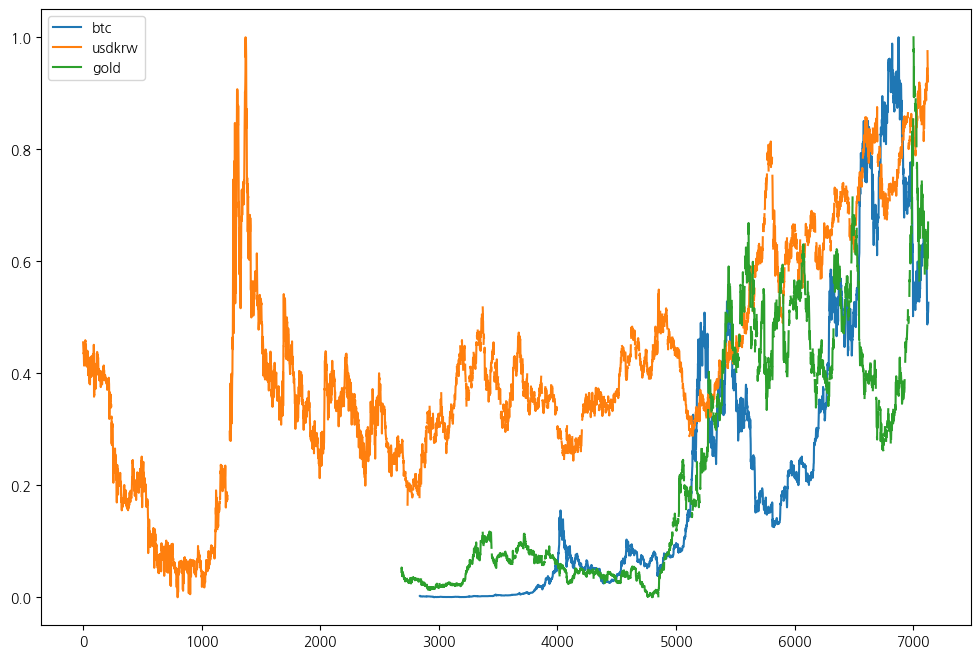

In [ ]:
# concated_df 정규화후 비교시각화
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
close_df = scaler.fit_transform(concated_df[['btc_Close', 'usdkrw_Close', 'gold_Close']])
close_df = pd.DataFrame(close_df, columns=['btc_Close', 'usdkrw_Close', 'gold_Close'])
display(close_df.head())

fig = plt.figure(figsize=(12, 8))
ax1=plt.plot(close_df.index, close_df['btc_Close'], label='btc')
ax2=plt.plot(close_df.index, close_df['usdkrw_Close'], label='usdkrw')
ax3=plt.plot(close_df.index, close_df['gold_Close'], label='gold')
plt.legend()
plt.show()

In [ ]:
# 한국증시 전체
krx = fdr.StockListing('KRX')
krx['marketRate'] = round(krx['Marcap'] / krx['Marcap'].sum() * 100, 2)
krx.sort_values(by='marketRate', ascending=False, inplace=True)
print(krx.shape)

# ETF 전체(ETF/KR)
etf = fdr.StockListing('ETF/KR')
etf['marketRate'] = round(etf['MarCap'] / etf['MarCap'].sum() * 100, 2)
etf.sort_values(by='marketRate', ascending=False, inplace=True)
print(etf.shape)

(2875, 18)
(1137, 13)


,Open,High,Low,Close,Volume,Adj Close
2019-12-31,5.772500,5.892000,5.753250,5.882500,231004000,5.849206
2020-01-02,5.968750,5.997750,5.918000,5.997750,237536000,5.963802
2020-01-03,5.877500,5.945750,5.852500,5.901750,205384000,5.868347
2020-01-06,5.808000,5.931750,5.781750,5.926500,262636000,5.892957
2020-01-07,5.955000,6.044250,5.909750,5.998250,314856000,5.964300
...,...,...,...,...,...,...
2026-06-09,210.619995,211.399994,199.339996,208.190002,180962500,208.190002
2026-06-10,204.429993,207.220001,199.919998,200.419998,161746600,200.419998
2026-06-11,201.490005,205.660004,199.539993,204.869995,158643200,204.869995
2026-06-12,204.860001,207.070007,203.440002,205.190002,112001800,205.190002


In [84]:
fdr.StockListing('NASDAQ')


100%|██████████| 3916/3916 [00:09<00:00, 403.32it/s]


,Symbol,Name,IndustryCode,Industry
0,NVDA,NVIDIA Corp,57101010,반도체
1,AAPL,Apple Inc,57106020,전화 및 소형 장치
2,MSFT,Microsoft Corp,57201020,소프트웨어
3,AMZN,Amazon.com Inc,53402010,백화점
4,SPCX,Space Exploration Technologies Corp,57401020,무선 통신 서비스
...,...,...,...,...
3911,OST,Ostin Technology Group Co. Ltd,57104010,전자 장비 및 부품
3912,CREG,Smart Powerr Corp,50201010,재생 가능 에너지 장비 및 서비스
3913,RNBW,Rainbow Capital Holdings Ltd,,
3914,FGXCU,FG Merger III Units,55601010,투자 지주 회사


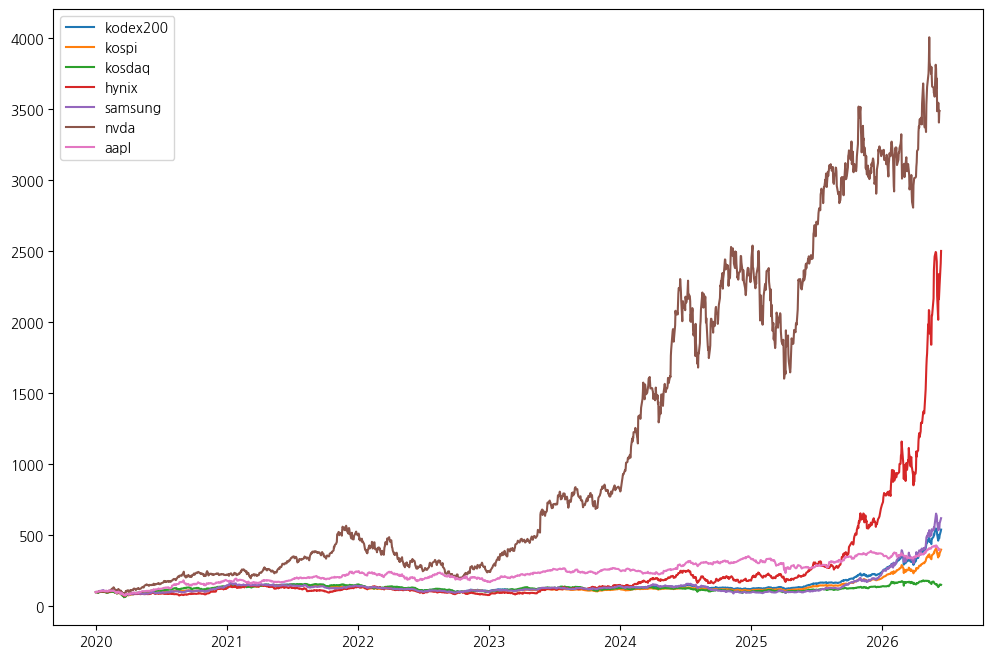

In [90]:
date = '2020-01-01'

kodex200 = fdr.DataReader('069500',date)
kospi = fdr.DataReader('KOSPI',date)
kosdaq = fdr.DataReader('KOSDAQ',date)
hynix = fdr.DataReader('000660',date)
samsung = fdr.DataReader('005930',date)
nvda = fdr.DataReader('NVDA',date)
aapl = fdr.DataReader('AAPL',date)

kodex200['index'] = (kodex200['Close'] / kodex200['Close'].iloc[0]) * 100
kospi['index'] = (kospi['Close'] / kospi['Close'].iloc[0]) * 100
kosdaq['index'] = (kosdaq['Close'] / kosdaq['Close'].iloc[0]) * 100
hynix['index'] = (hynix['Close'] / hynix['Close'].iloc[0]) * 100
samsung['index'] = (samsung['Close'] / samsung['Close'].iloc[0]) * 100
nvda['index'] = (nvda['Close'] / nvda['Close'].iloc[0]) * 100
aapl['index'] = (aapl['Close'] / aapl['Close'].iloc[0]) * 100

fig = plt.figure(figsize=(12, 8))
ax1=plt.plot(kodex200['index'], label='kodex200')
ax2=plt.plot(kospi['index'], label='kospi')
ax3=plt.plot(kosdaq['index'], label='kosdaq')
ax4=plt.plot(hynix['index'], label='hynix')
ax5=plt.plot(samsung['index'], label='samsung')
ax6=plt.plot(nvda['index'], label='nvda')
ax7=plt.plot(aapl['index'], label='aapl')
plt.legend()
plt.show()


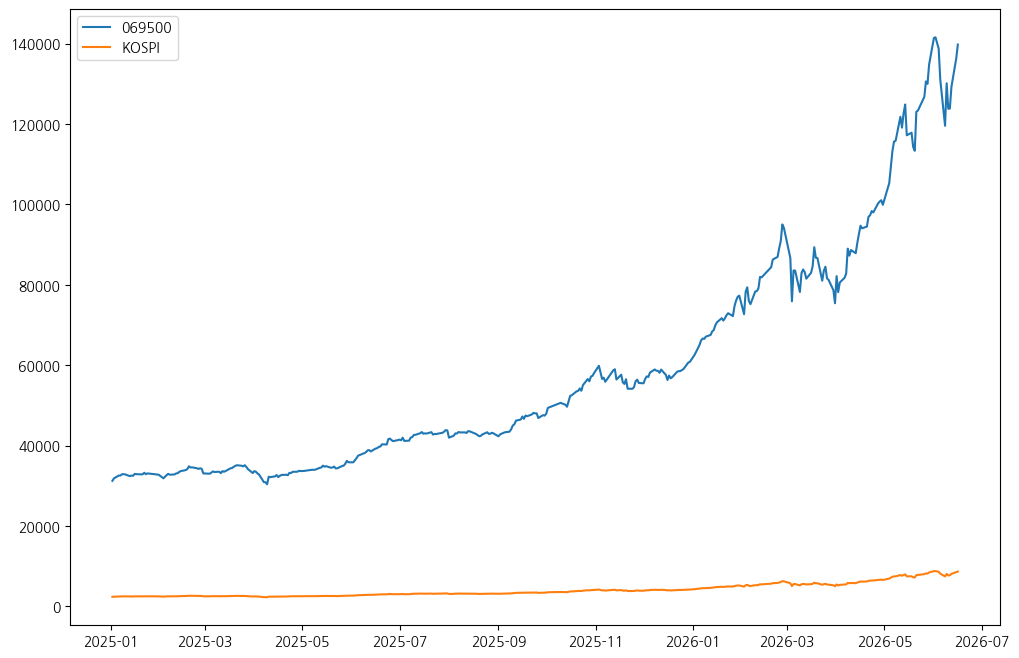

In [ ]:
fig = plt.figure(figsize=(12, 8))
kodex200 = fdr.StockListing('069500','2025-01-01')
kospi = fdr.StockListing('KOSPI','2025-01-01')


ax1=plt.plot(fdr.DataReader('069500','2025-01-01')['Close'], label='069500')
ax2=plt.plot(fdr.DataReader('KOSPI','2025-01-01')['Close'], label='KOSPI')
plt.legend()
plt.show()

,Close,UpDown,Comp,Change,Open,High,Low,Volume,Amount,MarCap
Date,,,,,,,,,,
2010-01-04,1696.14,1,13.37,0.0079,1681.71,1696.14,1681.71,296547959,4364595613797,8.947316e+14
2010-01-05,1690.62,2,-5.52,-0.0033,1701.62,1702.39,1686.45,408854057,6830723338336,8.919010e+14
2010-01-06,1705.32,1,14.70,0.0087,1697.88,1706.89,1696.10,426040121,6391016648164,8.996451e+14
2010-01-07,1683.45,2,-21.87,-0.0128,1702.92,1707.90,1683.45,462402742,7498405146704,8.881114e+14
2010-01-08,1695.26,1,11.81,0.0070,1694.06,1695.26,1668.84,379952313,6965072761490,8.940801e+14
...,...,...,...,...,...,...,...,...,...,...
2026-06-10,7730.82,2,-366.11,-0.0452,7899.77,7996.68,7541.11,460876834,39944843351120,6.324686e+15
2026-06-11,7763.95,1,33.13,0.0043,7509.62,7800.62,7394.46,478729575,46400773002266,6.352556e+15
2026-06-12,8123.62,1,359.67,0.0463,8263.85,8434.40,8079.77,493405620,52257643902434,6.649271e+15


In [57]:
krx

,Code,ISU_CD,Name,Market,Dept,Close,ChangeCode,Changes,ChagesRatio,Open,High,Low,Volume,Amount,Marcap,Stocks,MarketId,marketRate
0,005930,KR7005930003,삼성전자,KOSPI,NaN,340000,1,3000,0.89,343000,345500,332500,10034714,3402257242500,1987734726720000,5846278608,STK,25.86
1,000660,KR7000660001,SK하이닉스,KOSPI,NaN,2352000,1,64000,2.80,2381000,2400000,2286000,1941247,4564899633500,1676275962480000,712702365,STK,21.81
2,402340,KR7402340004,SK스퀘어,KOSPI,NaN,1475000,1,62000,4.39,1440000,1483000,1380000,333798,478882458000,194638619350000,131958386,STK,2.53
3,005935,KR7005931001,삼성전자우,KOSPI,NaN,221500,1,5500,2.55,220000,224500,216000,1726712,379363858500,177725221464500,802371203,STK,2.31
4,009150,KR7009150004,삼성전기,KOSPI,NaN,2038000,1,39000,1.95,2042000,2067000,1970000,663626,1341320064500,152225752448000,74693696,STK,1.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1380,078890,KR7078890001,가온그룹,KOSDAQ,중견기업부,5900,1,40,0.68,5910,6030,5800,183322,1079243195,108707163700,18424943,KSQ,0.00
1381,451220,KR7451220008,아이엠티,KOSDAQ,기술성장기업부,13790,2,-20,-0.14,13730,14060,13460,57338,790814170,108590885690,7874611,KSQ,0.00
1382,141000,KR7141000000,비아트론,KOSDAQ,벤처기업부,8960,2,-210,-2.29,9170,9330,8890,11753,106485965,108547801600,12114710,KSQ,0.00
1383,205100,KR7205100001,엑셈,KOSDAQ,벤처기업부,1534,2,-71,-4.42,1598,1640,1531,641747,995774137,108432972882,70686423,KSQ,0.00


In [ ]:
def find_stock_code(name):
    df_kospi = fdr.StockListing('KOSPI')
    if df[df['Name']].str.contains(name).any():
        return df[df['Name'] == name]['Code'].values[0]
    else:
        return print('존재하지 않는 종목입니다.')

find_stock_code('삼성전자')




KeyError: "None of [Index(['삼성전자', 'SK하이닉스', 'SK스퀘어', '삼성전자우', '삼성전기', '현대차', 'LG에너지솔루션', '삼성생명',\n       '삼성물산', 'HD현대중공업',\n       ...\n       '유유제약2우B', '성문전자우', '동양2우B', '깨끗한나라우', '남선알미우', '동양우', '진흥기업우B',\n       '진흥기업2우B', 'CJ씨푸드1우', '서울식품우'],\n      dtype='object', length=946)] are in the [columns]"